### Table of Contents


1. "gpa_by_section" function
2. average grade by student year and student level (table 2)
3. total enrollment by student year nad course level (table 3)
4. distribution of student weighted GPAs (fig 1)
5. scatterplots + kurtosis and skewness computation
    a. scatterplot (inst avg GPA vs enrollment) generator
    b. histogram (distribution to visualize kurtosis/skewness) generator
6. sez score computing
7. clustering 
    a. output cluster average grade dist
    b. output course cluster dist by dept (table 5)
    c. find grade distribution parallel plot for different dept of choice (fig 5 but custom)


In [1]:
# libraries required
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import kurtosis, skew
from sklearn.cluster import KMeans

In [2]:
# get df from csv (in local directory) [MUST REPLACE BELOW PATH TO YOURS]
df = pd.read_csv(r'C:\Users\jeong\research\grading-data-6-17-22.csv')

# general tools
# returns filtered dataframe. Each condition should be passed as column name = LIST of targets
    # e.g. "filter(df, crsTitle = ['PHYSICS I LAB'], facultyID = ['F18125', 'F97128'])" returns df with 84 rows
def filter(df, **kwargs):
    for key in kwargs.keys():
        df = df[(df[key]).isin(kwargs.get(key))]
    return df

# fx to return cleaned+organized df
def clean_df(df):
    df = df.copy()
    df.replace(" ", np.nan, inplace=True)
    # finGradN to type float, facultyID to type str
    df['finGradN'] = df['finGradN'].astype('float')
    df['facultyID']=df['facultyID'].astype(str)
    # drop administrative CBA/FCRH as they are not actual students
    df.drop(df[df['ProgCode'] == 'Administrative CBA'].index,  inplace = True)
    df.drop(df[df['ProgCode'] == 'Administrative FCRH'].index, inplace = True)
    # create newCRN (CRN + last two digits of year + one digit based on semester) (e.g. oldCRN 11135, Summer 2010 course -> CRN: 11135102)
    df[['sem', 'year']] = df['term'].str.split(' ', n = 1, expand = True)
    df['year'] = pd.to_numeric(df['year'])
    df['year'] = df.apply(lambda x: x['year'] % 1000, axis=1)
    df.loc[df['sem'] == 'Fall', 'sem'] = 2
    df.loc[df['sem'] == 'Spring', 'sem'] = 0
    df.loc[df['sem'] == 'Summer', 'sem'] = 1
    df['sem'] = pd.to_numeric(df['sem'])
    df.rename(columns = {'CRN':'oldCRN'}, inplace = True)
    df['oldCRN'] = df['oldCRN'].astype(str)
    df['year'] = df['year'].astype(str)
    df['sem'] = df['sem'].astype(str)
    df['CRN'] = df['oldCRN'] + df['year']+ df['sem']

    df['NumCode'] = df['NumCode'].fillna(0)
    df['NumCode'] = df['NumCode'].astype(int)
    df['NumCode'] = df['NumCode'].astype(str)
    df['CourseCode'] = df['ProgCode'] + " " + df['NumCode']

    return df

# original df remains unchanged. cleaned data is put in new dataframe final_df
final_df = clean_df(df)

# list of all semester+years represented in this df. excludes 162(2016 Fall) b/c there are <20 data points.
yearlist = []
for i in range(10, 19):
    for j in [0,2]:
        yearlist.append(10*i+j)
yearlist.remove(100)
yearlist.remove(182)
yearlist.remove(162)

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
# 1. "gpa_by_section" function
    # input: dataframe, name of course as string
    # returns list of each section: provides CRN(newCRN that is unique to section), Instructor(facultyID), average GPA, SD, class size (of section)
    # e.g. try: gpa_by_section(final_df, "English 2000")
def gpa_by_section(df, course_name):
    sections = list(np.unique((filter(df, CourseCode = [course_name])['CRN'])))
    to_return = pd.DataFrame(columns =['CRN', 'Instructor', 'GPA', 'SD', 'Class Size'])
    for i in sections:
        filtered_data = filter(df, CourseCode = [course_name], CRN = [i])
        to_return.loc[len(to_return)] = [i, (filtered_data.mode()['facultyID'][0]), np.mean(((filtered_data)['finGradN']).to_numpy()), np.std(((filtered_data)['finGradN']).to_numpy()), len(filtered_data.index)]
    to_return['total'] = to_return['GPA']*to_return['Class Size']
    to_return['CRN']=pd.to_numeric(to_return['CRN'])
    to_return['semyear']=to_return['CRN'] % 1000
    return to_return

In [5]:
# 2. average grade by student year and student level (table II in paper)

sp_df = final_df.copy()
sp_df.loc[sp_df['STU_ulevel'] == "Continuing Freshman", "STU_ulevel"] = "Freshman"
sp_df.loc[sp_df['STU_ulevel'] == "First-Time Freshman", "STU_ulevel"] = "Freshman"
stu_list = ['Freshman', 'Sophomores', 'Juniors', 'Seniors']
lev_list = [1,2,3,4]
course_level_list = list(([(int(i)//1000) for i in list((sp_df['NumCode']))]))
sp_df['CourseLevel'] = course_level_list
stu_yr_lev_table = pd.DataFrame(columns = ["Student Year", 1000, 2000, 3000, 4000])

for i in stu_list:
    current_row = []
    current_row.append(i)
    for l in lev_list:
        current_df = sp_df[(sp_df['STU_ulevel']==i) & (sp_df['CourseLevel']==l)]
        current_row.append((np.mean(list(current_df['finGradN']))))
    stu_yr_lev_table.loc[len(stu_yr_lev_table)] = current_row

stu_yr_lev_table

,Student Year,1000,2000,3000,4000
0,Freshman,3.109456,3.276386,3.037274,3.235132
1,Sophomores,3.190316,3.284286,3.217221,3.256736
2,Juniors,3.168518,3.313185,3.281391,3.321765
3,Seniors,3.184161,3.347911,3.332972,3.411406


In [6]:
# 3. total enrollment by student year nad course level (table III in paper)
    # raw numbers: stu_yr_lev_enr_table
    # percentage: by_percentage
stu_yr_lev_enr_table = pd.DataFrame(columns = ["Student Year", 1000, 2000, 3000, 4000])

for i in stu_list:
    current_row = []
    current_row.append(i)
    for l in lev_list:
        current_df = sp_df[(sp_df['STU_ulevel']==i) & (sp_df['CourseLevel']==l)]
        current_row.append((len(list(current_df['finGradN']))))
    stu_yr_lev_enr_table.loc[len(stu_yr_lev_enr_table)] = current_row

by_percentage = stu_yr_lev_enr_table.copy()
by_percentage = by_percentage.drop(columns=['Student Year'])
by_percentage['ttl'] = by_percentage.sum(axis=1)
total_count = np.sum(list(by_percentage['ttl']))

def find_percentage(count):
    return 100*(count/total_count)
by_percentage = by_percentage.drop(columns=['ttl'])
by_percentage = by_percentage.apply(find_percentage)
by_percentage.insert(0, "Student Year", stu_list)

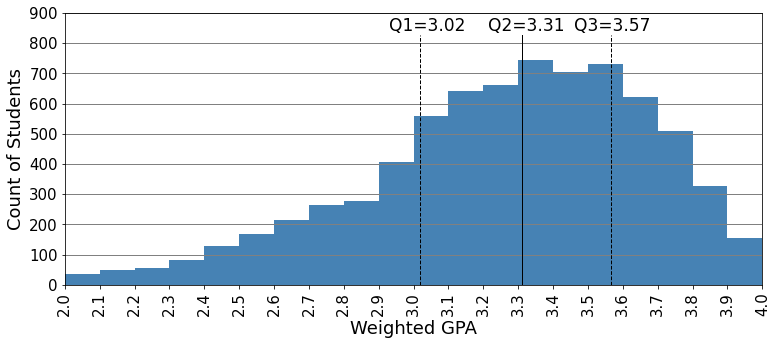

In [7]:
# 4. distribution of student weighted GPAs (fig 1 in paper)
    # input: minimum number cutoff of classes a student has to take to make it onto the graph

    # warning: this takes a long time.
    
min_classes = 25
font_size = 18
bin_list = np.arange(2.0, 4.1, 0.1)
plt.figure(figsize=(12.5,5)) 

list_stus = list(np.unique(list(final_df['SID'])))
list_stulev_gpa = []
with_ttl_df = final_df.copy()
with_ttl_df['ttl'] = with_ttl_df.apply(lambda row: (row['credHrs']*row['finGradN']), axis=1)

for i in list_stus:
    filtered_df = with_ttl_df[with_ttl_df["SID"]==i]
    if len(filtered_df.index)>=min_classes:
        list_stulev_gpa.append(np.sum(list(filtered_df['ttl']))/np.sum(list(filtered_df['credHrs'])))

plt.hist(list_stulev_gpa, bins=bin_list, color="steelblue")

plt.axvline(x = (np.percentile(list_stulev_gpa, 25)), ymin=0, ymax= 0.92, color = 'black', lw=1, ls="--")
plt.text((np.percentile(list_stulev_gpa, 25))*0.97, 840, ("Q1="+str(round(((np.percentile(list_stulev_gpa, 25))), 2))), fontsize=font_size-1)
plt.axvline(x = (np.percentile(list_stulev_gpa, 50)), ymin=0, ymax= 0.92, color = 'black', lw=1)
plt.text((np.percentile(list_stulev_gpa, 50))*0.97, 840, ("Q2="+str(round((np.percentile(list_stulev_gpa, 50)), 2))), fontsize=font_size-1)
plt.axvline(x = (np.percentile(list_stulev_gpa, 75)), ymin=0, ymax= 0.92, color = 'black', lw=1, ls="--")
plt.text((np.percentile(list_stulev_gpa, 75))*0.97, 840, ("Q3="+str(round((np.percentile(list_stulev_gpa, 75)), 2))), fontsize=font_size-1)

plt.xlim(2.0, 4.0)
plt.ylim(0, 900)

plt.xlabel('Weighted GPA', fontsize = font_size)
plt.ylabel('Count of Students', fontsize = font_size)
plt.grid(True, axis="y", color = "grey", linewidth = "1")

plt.xticks(bin_list, rotation='vertical',fontsize=font_size-3, color="black")
plt.yticks(fontsize=font_size-3, color="black")
plt.show()

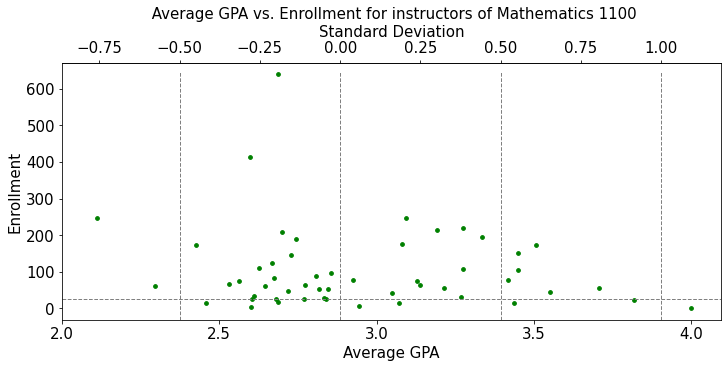

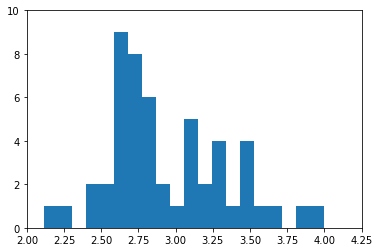

kurtosis: -0.1503899668642803
skew: 0.5405377085124103


In [8]:
# 5. scatterplots + kurtosis and skewness computation
    # a. scatterplot (inst avg GPA vs enrollment) generator
        # WARNING: takes about 15 seconds per subject

# for each course
    # put subject to generate scatterplot below
subj = "Mathematics 1100"
subj_ins = np.unique(list((final_df[final_df['CourseCode'] == subj])['facultyID']))
subj_avg = np.mean(list((final_df[final_df['CourseCode'] == subj])['finGradN']))
subj_std = np.std(list((final_df[final_df['CourseCode'] == subj])['finGradN']))

subj_gpa = []
subj_enr = []

for i in subj_ins:
    subj_gpa.append(np.mean((final_df[(final_df['facultyID'] == i) & (final_df['CourseCode'] == subj)])['finGradN']))
    subj_enr.append(len((final_df[(final_df['facultyID'] == i) & (final_df['CourseCode'] == subj)]).index))

font_size = 15
fig, ax = plt.subplots(constrained_layout=True)
x = subj_gpa
y = subj_enr
ax.scatter(x, y, s=14, c= "green")
ax.set_xlabel('Average GPA', fontsize = font_size)
ax.set_ylabel('Enrollment', fontsize = font_size)
plt.xticks(np.arange(2.0, 4.5, 0.5))

f = lambda x: (x-subj_avg)/subj_std
g = lambda x: x*subj_std+subj_avg

secax = ax.secondary_xaxis('top', functions=(f, g))
secax.set_xlabel('Standard Deviation', fontsize = font_size)
secax.tick_params(labelsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.grid(False)

extraticks = []
for i in np.arange(subj_avg-3*subj_std, subj_avg+3.5*subj_std, subj_std*0.5):
    if (i>=2 and i<=4):
        extraticks.append(round(i,2))
        plt.axvline(x = i, ymin=0, ymax= 0.97, color = 'gray', ls='--', lw=1)

if min(subj_gpa) < 2.0:
    print("Lower than 2.0 exception")

plt.axhline(y = (np.mean(list((gpa_by_section(final_df, subj))['Class Size']))), color = 'gray', ls='--', lw=1)
plt.title(label=(" Average GPA vs. Enrollment for instructors of "+subj), fontsize=font_size)
plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
plt.gcf().set_size_inches((10,5))    
plt.show()    


    #b. histogram (distribution to visualize kurtosis/skewness) generator
plt.hist(subj_gpa, 20)
plt.show()

    #c. kurtosis and skewness
print("kurtosis: "+str(kurtosis(subj_gpa, bias =True, fisher=True)))
print("skew: "+str(skew(subj_gpa, axis=0, bias=True)))

In [9]:
# 6. sez score computing
def find_metric(master_df, course, i):
    new_master = master_df[master_df['CourseCode'] == course]
    instructor_df = new_master[new_master['facultyID'] == i]
    rest_df = new_master[new_master['facultyID'] != i]
    if (len(instructor_df.index)>0):
        to_return = (np.mean(list(instructor_df['finGradN'])) - np.mean(list(rest_df['finGradN'])))/np.std(list(rest_df['finGradN']))
    return to_return

# example 
find_metric(final_df, "Mathematics 1100", "F17127")

-0.8038993690138515

In [10]:
# 7. clustering
# create grade distribution vector table for all courses (identified with CourseCode column)
# WARNING: takes approx. 2 mins

letter_gpa_list_undergrad = ['A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D', 'F']
crs_grade_distribution_v_df = pd.DataFrame(columns = ['CourseCode']+letter_gpa_list_undergrad+['TotalEnrollment'])

for cs in list(np.unique(list(final_df['CourseCode']))):
    subj = cs
    raw_grade_list = (list((final_df[final_df['CourseCode'] == subj])['finGradC']))
    counts = dict()
    for i in raw_grade_list:
        counts[i] = counts.get(i, 0) + 1
    grade_dis_v = []
    ttl_enr = len(raw_grade_list)
    for i in letter_gpa_list_undergrad:
        if i in list(counts.keys()):
            grade_dis_v.append(counts[i])
        else:
            grade_dis_v.append(0)
    crs_grade_distribution_v_df.loc[len(crs_grade_distribution_v_df)] = [subj]+grade_dis_v+[ttl_enr]
crs_grade_distribution_v_df

,CourseCode,A,A-,B+,B,B-,C+,C,C-,D,F,TotalEnrollment
0,African & African Amer Studies 1100,5,3,6,9,0,2,2,1,0,0,28
1,African & African Amer Studies 1200,5,0,0,0,0,0,0,0,0,0,5
2,African & African Amer Studies 1201,2,0,0,0,0,0,0,0,0,0,2
3,African & African Amer Studies 1600,208,190,204,134,67,28,8,4,5,6,854
4,African & African Amer Studies 1601,2,13,7,10,1,0,0,0,1,0,34
...,...,...,...,...,...,...,...,...,...,...,...,...
2656,"Women, Gender, & Sexuality St 4105",2,1,3,2,0,0,1,0,0,0,9
2657,"Women, Gender, & Sexuality St 4127",1,1,1,0,1,0,0,0,0,0,4
2658,"Women, Gender, & Sexuality St 4400",4,0,1,0,0,0,0,0,0,1,6
2659,"Women, Gender, & Sexuality St 4920",1,0,0,0,0,0,0,0,0,0,1
